In [26]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import astropy.units as u

from config.plotting import save_figure, set_plotting_defaults, Tab10, royalblue_palette
from config.units import Gauss, flux_unit
from spectrum_fit_electrons import JointSteadyStateFit
from config.settings import MCMC_ELECTRONS_STEADY_JOINT, SPECTRUM_DIR, SYNCH_INTERP_DIR
from src.electron_timescales import synchrotron_timescale
from src.synchrotron_emission import electron_synchrotron_emission_power, electron_synchrotron_emission_luminosity

set_plotting_defaults()

In [27]:
nsteps, nwalkers = 600, 32
bvalue = 6e-6

data = pickle.load(open(os.path.join(MCMC_ELECTRONS_STEADY_JOINT,
                                     f"joint_{nsteps}n_{nwalkers}w_{bvalue * 1e6:.1f}uG.pck"), "rb"))

result, joint = data[0], data[1]

In [28]:
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))

names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data

In [29]:
result_mod = result[(result[:, 0] < -1) * (result[:, 1] < 3)] # * (result[:, 1] > 1.5)]
result_mod2 = result_mod# [abs(result_mod[:, 2] - 3.0) < 2.5]

In [30]:
spectra = []
for i, res in enumerate(result_mod2[::]):
    spectra.append(joint.model(res))

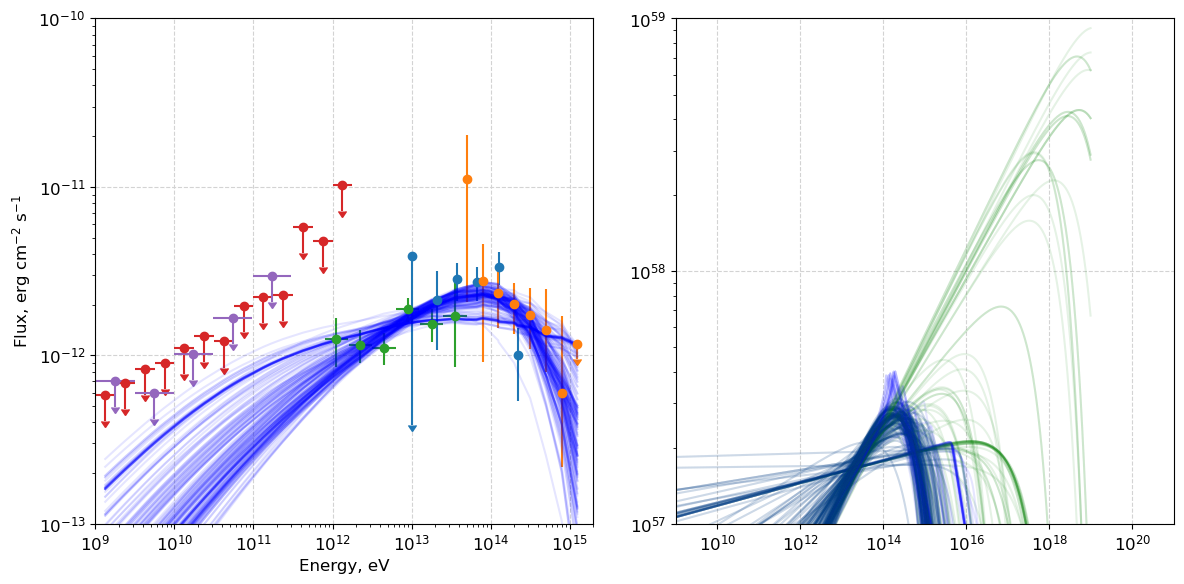

In [31]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0,
                 color=Tab10[i], label=f' ')

set_plotting_defaults()
for i, res in enumerate(result_mod2[::]):
    plt.subplot(1, 2, 1)
    plt.plot(joint.photon_energy, spectra[i], alpha=.1, color='blue')
    plt.subplot(1, 2, 2)
    jee = joint.electron_energy
    plt.loglog(jee, jee**2 * joint.spectrum.dn_de(jee, eta=res[0], p=res[1], k1=joint.k10, k2=res[2]), alpha=.1, color='green')
    plt.loglog(jee, jee**2 * joint.cooled_spectrum(res), alpha=.1, color='blue')

plt.subplot(1, 2, 1)
plt.xscale('log')
plt.xlim(1e9, 2e15)
plt.xlabel("Energy, eV")

plt.yscale('log')
plt.ylim(1e-13, 1e-10)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")
plt.tight_layout()
# save_figure(f"electron_fit_mcmc_{bvalue * 1e6:.1f}uG")

plt.subplot(1, 2, 2)
plt.xlim(1e9, 1e21)
plt.ylim(1e57, 1e59)
plt.show()

In [32]:
print(np.mean(result_mod2, axis=0))
k = np.argmax(result_mod2[:, 3])
print(f"{joint.times[int(result_mod2[k, 3])]:.0f}")
print(result_mod2[k])
print(np.max(result_mod2, axis=0))
print(np.min(result_mod2, axis=0))

[-2.52082436e+00  1.74924524e+00  3.85039419e+00  3.84424646e+03]
2877 yr
[-2.92446272e+00  1.65978030e+00  7.13280006e+00  7.83435636e+03]
[-1.66047280e+00  1.99784750e+00  7.51958437e+00  7.83435636e+03]
[-3.1932639   1.51294539  2.47471978 13.78862661]


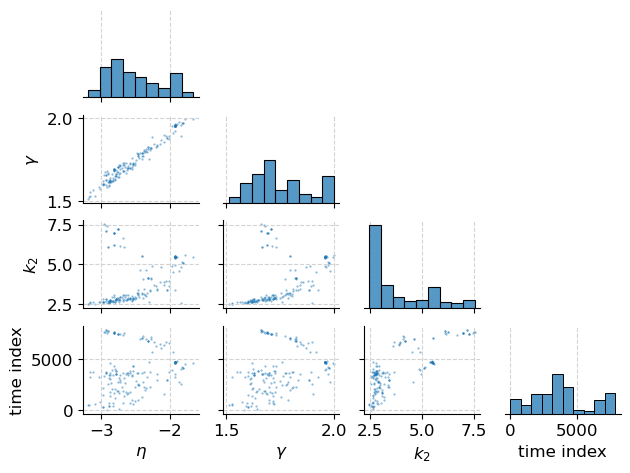

In [33]:
columns = [r"$\eta$", r"$\gamma$", r"$k_2$", r"time index"]
fs = pd.DataFrame(result_mod2, columns=columns)

g = sns.pairplot(fs, diag_kind="hist",
                plot_kws=dict(marker=".", linewidth=0, alpha=.5, s=10),
                corner=True, height=1.2, aspect=4/3)
# g.map_lower(sns.kdeplot, levels=5, color=".2", alpha=.3)
# save_figure(f"pairplot{nsteps}")
plt.show()

7834
2876.9057189019472 yr


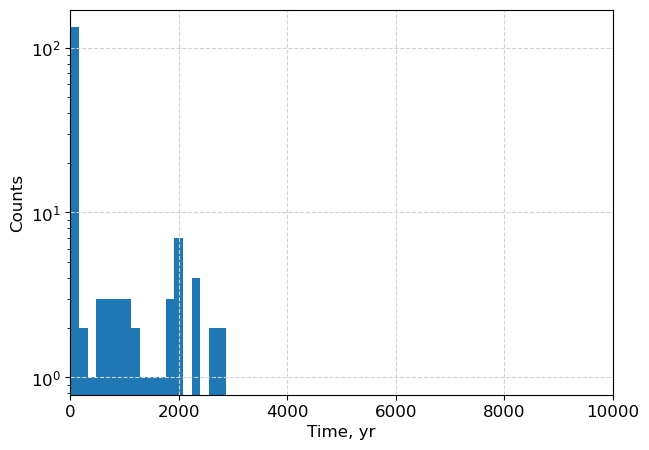

In [34]:
times = np.int_(result_mod2[:, 3])
x = np.max(times)
print(x)
print(joint.times[x])
plt.hist(joint.times[times], bins=18)

plt.xlabel(r"Time, yr")
plt.ylabel(r"Counts")
plt.xlim(0, 10000)
plt.yscale("log")
plt.show()

In [35]:
from analysis_electrons.general_spectrum_analysis import volume_approximation, width_approximation, length_approximation

# calculate the synchrotron_emission
bfield = bvalue * Gauss
synch_photon_energy = np.logspace(-8, 15, 100) * u.eV
result_chosen = np.sort(result_mod2)

# print(result_chosen)

In [36]:
from spectrum.measurements_xray import constraint_XRISM, constraint_Chandra, weak_constraint_XRISM

In [37]:
# XRISM ISOTROPIC AREA APPROXIMATION

amin_pc = 1/60 * 115 * u.pc / u.arcmin
XRISM_area = (629.4 * u.arcmin**2) * amin_pc**2

wl_ratio = 1/3.56
size_HESS = 110 * u.pc
energy_HESS = 40 * u.TeV
size_1TeV = size_HESS * (1 * u.TeV / energy_HESS)**(1/6)

print(size_1TeV)

e_volume = volume_approximation(joint.electron_energy, width_length_ratio=wl_ratio, size_1TeV=size_1TeV)
e_width  = width_approximation(joint.electron_energy, width_length_ratio=wl_ratio, size_1TeV=size_1TeV)
e_length = length_approximation(joint.electron_energy, size_1TeV=size_1TeV)

59.48160609161094 pc


In [38]:
# DEPRECATED, NOW I USE MONTE-CARLO SIMULATION
def XRISM_dif_area_profile(l_par, l_bot):
    phi0 = 45
    delta_phi = 23.48

    phi1 = np.deg2rad(np.arange(0, 360, 0.01))
    phi2 = np.deg2rad(-phi0 + np.arange(-delta_phi, delta_phi, 0.01))

    r1 = 12 * u.arcmin * amin_pc
    r2 = 24 * u.arcmin * amin_pc

    a1 = np.cos(phi1)**2 / l_bot**2 + np.sin(phi1)**2 / l_par**2
    int1 = np.trapezoid(1/a1 * (1 - np.exp(-a1 * r1**2)), phi1)

    a2 = np.cos(phi2)**2 / l_bot**2 + np.sin(phi2)**2 / l_par**2
    int2 = np.trapezoid(1/a2 * (np.exp(-a2 * r1**2) - np.exp(-a2 * r2**2)), phi2)

    return 1 / (2 * np.pi * l_par * l_bot) * (int1 + int2)



In [39]:
# DEPRECATED, NOW I USE MONTE-CARLO SIMULATION
def XRISM_area_profile(f1, *args):
    r1 = np.linspace(0, 12, 51) * u.arcmin * amin_pc                  # circle radii
    phi1 = np.deg2rad(np.arange(0, 360, 0.1))                        # circle angles

    rphi1, phir1 = np.meshgrid(r1, phi1, indexing='ij')
    vals1 = rphi1 * f1(rphi1, phir1, *args)
    vals_int1 = np.trapezoid(np.trapezoid(vals1, r1, axis=0), phi1)

    phi0 = 45
    delta_phi = 23.48
    r2 = np.linspace(12, 24, 101) * u.arcmin * amin_pc                 # ring element radii
    phi2 = np.deg2rad(-phi0 + np.arange(-delta_phi, delta_phi, 0.1))  # ring element angles

    rphi2, phir2 = np.meshgrid(r2, phi2, indexing='ij')
    vals2 = rphi2 * f1(rphi2, phir2, *args)
    vals_int2 = np.trapezoid(np.trapezoid(vals2, r2, axis=0), phi2)

    return vals_int1 + vals_int2


def unit_function(r, phi, l_par, l_bot):
    return (np.heaviside(l_bot / 2 - np.abs(r * np.cos(phi)), 1.0) *
            np.heaviside(l_par / 2 - np.abs(r * np.sin(phi)), 1.0) / (l_bot * l_par))


def diffusion_function(r, phi, l_par, l_bot):
    return 1/(np.pi * l_par * l_bot) * np.exp(-(r * np.cos(phi) / l_bot)**2 - (r * np.sin(phi) / l_bot)**2)

print(XRISM_area_profile(unit_function, 100 * u.pc, 30 * u.pc))
print(XRISM_area_profile(diffusion_function, 100 * u.pc/2, 30 * u.pc/2))
print(XRISM_dif_area_profile(100 * u.pc/2, 30 * u.pc/2))

0.44664773384381934
0.27500255985375105
0.45353679494107185


In [40]:
import scipy.stats as stats
from spectrum.Xrism_area_energy_dependence import XrismArea

n_dots = 10000

uniform_slab    = stats.uniform(loc=[-1.0, -1.0], scale=[2.0, 2.0])
diffusive_slab  = stats.norm(loc=[0.0, 0.0], scale=[0.5, 0.5])

p_u = uniform_slab.rvs(size=[n_dots, 2])
x_u, y_u = p_u[:, 0], p_u[:, 1]

p_d = diffusive_slab.rvs(size=[n_dots, 2])
x_d, y_d = p_d[:, 0], p_d[:, 1]

xa = XrismArea()

def XRISM_ratio_uniform(hw_x, hw_y):
    x1_u, y1_u = x_u * hw_x, y_u * hw_y
    return xa.count(x1_u, y1_u) / n_dots

def XRISM_ratio_diffusive(hw_x, hw_y):
    x1_d, y1_d = x_d * hw_x, y_d * hw_y
    return xa.count(x1_d, y1_d) / n_dots

In [41]:
# SYNCHROTRON

path = os.path.join(SYNCH_INTERP_DIR, f"synch_power_interp_{bfield.value * 1e6:.1f}.pck")
synch_interp_data = pickle.load(open(path, "rb"))

synch_interp = synch_interp_data[2]

lg_ee = np.log10(joint.electron_energy.value)
lg_pe = np.log10(synch_photon_energy.value)
ee_pe, pe_ee = np.meshgrid(lg_ee, lg_pe, indexing='ij')
synch_table = 10**synch_interp((ee_pe, pe_ee)) * (1/u.s)

norm_dA, dif_dA = [], []
for i, e in enumerate(joint.electron_energy):
    hw_x1, hw_y1 = e_width[i] / 2, e_length[i] / 2
    norm_dA.append(XRISM_ratio_uniform(hw_x1, hw_y1))
    dif_dA.append(XRISM_ratio_diffusive(hw_x1, hw_y1))

norm_dA, dif_dA = np.array(norm_dA), np.array(dif_dA)

0.001 TeV 2.6418167715510767 pc 9.404867706721832 pc
10.092621909870484 TeV 12.281083767459185 pc 43.720658212154696 pc
101861.01701559772 TeV 57.09140017867187 pc 203.24538463607183 pc


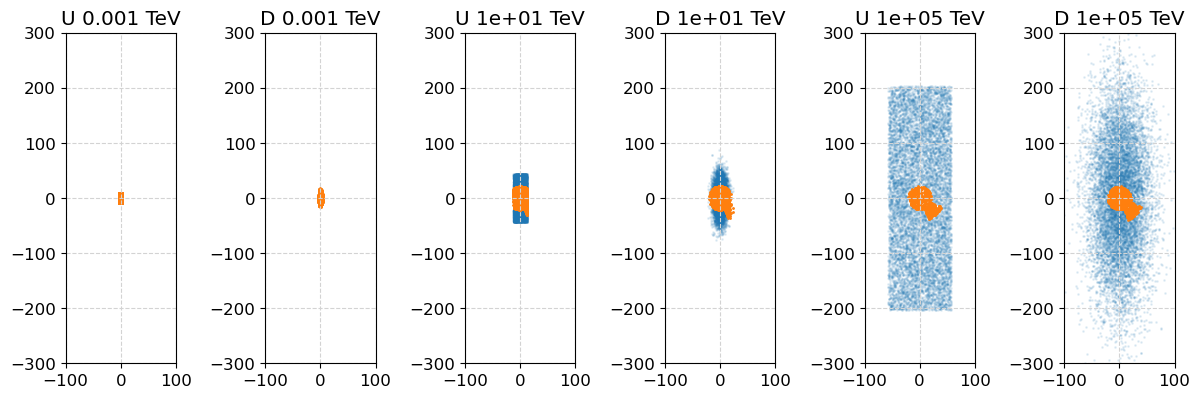

In [42]:
plt.figure(figsize=(16, 6))
cnt = 1

for i, e in enumerate(joint.electron_energy):
    if i % 200 != 0:
        continue
    print(e.to(u.TeV), e_width[i] / 2, e_length[i] / 2)

    plt.subplot(1, 8, 2 * cnt - 1)
    plt.title(f"U {e.to(u.TeV):.1g}")
    x2_u, y2_u = x_u * e_width[i] / 2, y_u * e_length[i] / 2
    x3u,y3u = xa.get(x2_u, y2_u)
    plt.scatter(x2_u, y2_u, s=1, alpha=0.1)
    plt.scatter(x3u, y3u, s=1)
    plt.gca().set_aspect('equal')
    plt.xlim(-100, 100)
    plt.ylim(-300, 300)

    plt.subplot(1, 8, 2*cnt)
    plt.title(f"D {e.to(u.TeV):.1g}")
    x2_d, y2_d = x_d * e_width[i] / 2, y_d * e_length[i] / 2
    x3d,y3d = xa.get(x2_d, y2_d)
    plt.scatter(x2_d, y2_d, s=1, alpha=0.1)
    plt.scatter(x3d, y3d, s=1)
    plt.gca().set_aspect('equal')
    plt.xlim(-100, 100)
    plt.ylim(-300, 300)

    cnt += 1

plt.tight_layout()
plt.show()

In [43]:
synch_flux_hom = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit
synch_flux_dif = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit
synch_flux_full = np.zeros([result_chosen.shape[0], synch_photon_energy.size]) * flux_unit

for i, res_i in enumerate(result_chosen):
    dN_dE = joint.cooled_spectrum(res_i)

    # Homogenous distribution of photons in the nebula
    dN_dE_XRISM1 = dN_dE * norm_dA
    synch_lum_hom = np.trapezoid(synch_table.T * dN_dE_XRISM1, joint.electron_energy, axis=1)
    synch_flux_hom[i] = synch_lum_hom * synch_photon_energy / joint.area

    # Purely diffusive electron distribution in the nebula
    dN_dE_XRISM2 = dN_dE * dif_dA
    synch_lum_dif = np.trapezoid(synch_table.T * dN_dE_XRISM2, joint.electron_energy, axis=1)
    synch_flux_dif[i] = synch_lum_dif * synch_photon_energy / joint.area

    # Total synchrotron emission
    synch_lum_full = np.trapezoid(synch_table.T * dN_dE, joint.electron_energy, axis=1)
    synch_flux_full[i] = synch_lum_full * synch_photon_energy / joint.area

In [44]:
uhe_photon_energy = np.logspace(8, 17, 100) * u.eV
_, joint.radiation_matrix = joint.set_radiation_matrix(electron_energy=joint.electron_energy,
                                                       photon_energy=uhe_photon_energy)
joint.photon_energy = uhe_photon_energy

In [45]:
from scipy.interpolate import splrep, splev

lg_phot_e = np.log10(uhe_photon_energy.value)
spectra = []
for i, res in enumerate(result_chosen):
    flux_bad = joint.model(res)
    spl = splrep(x=lg_phot_e, y=np.log10(flux_bad.value), s=0.1)
    flux = splev(lg_phot_e, spl)
    spectra.append(10**flux)

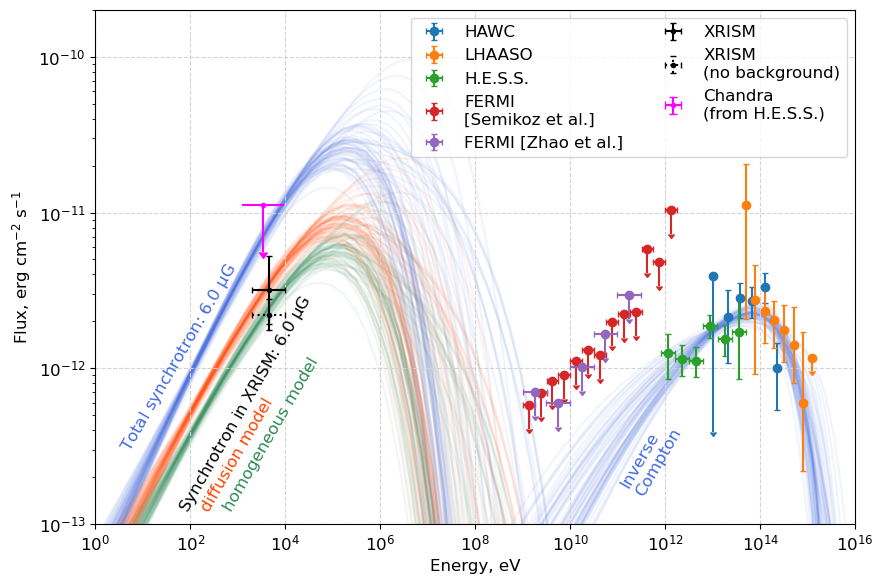

In [46]:
plt.figure(figsize=(9, 6))

# UHE spectrum
data = pickle.load(open(os.path.join(SPECTRUM_DIR, "UHE_spectrum_corrected.pck"), "rb"))
names, e, f_cor, f_l_cor, f_p_cor, e_l, e_p = data
names_short = ["HAWC", "LHAASO", "H.E.S.S.", "FERMI\n[Semikoz et al.]", "FERMI [Zhao et al.]"]
for i, name in enumerate(names):
    plt.errorbar(e[i], f_cor[i], xerr=[e_l[i], e_p[i]], yerr=[f_l_cor[i], f_p_cor[i]],
                 fmt='o', linestyle='None', uplims=f_p_cor[i] <= 0, capsize=2,
                 color=Tab10[i], label=names_short[i])
# X-Ray corrected
e, f, f_l, f_p, e_l, e_p = constraint_XRISM()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
             marker='o', markersize=3, label='XRISM', linestyle='None')
e, f, f_l, f_p, e_l, e_p = weak_constraint_XRISM()
eb = plt.errorbar(e, f, xerr=[e_l, e_p], yerr=[f_l, f_p], color='black', capsize=2,
                  marker='o', markersize=3, label='XRISM\n(no background)', linestyle='None')
eb[-1][0].set_linestyle(':')
e, f, f_l, f_p, e_l, e_p = constraint_Chandra()
plt.errorbar(e, f, xerr=[e_l, e_p], yerr=0.5 * f, uplims=True,
             marker='o', markersize=3, label='Chandra\n(from H.E.S.S.)', linestyle='None',
             color='magenta')
plt.errorbar(1, 1, linewidth=0, label=' ', marker=None)

g_a = .07
for i, res in enumerate(result_chosen):
    if res[-2] > 4.3 or res[-1] < 3000:
        continue
    """print(res)
    print(i)
    time = joint.times[int(res[-1])]
    print(time)"""
    # result = [joint.photon_energy, synch_photon_energy, spectra[i], synch_flux_dif[i], synch_flux_full[i]]
    # pickle.dump(result, open(os.path.join(SPECTRUM_DIR, "fit_steady.pck"), "wb"))
    # plot gamma-ray spectrum
    plt.plot(joint.photon_energy, spectra[i], alpha=g_a, color="royalblue", zorder=0)
    # plot synchrotron spectrum
    plt.plot(synch_photon_energy, synch_flux_hom[i], alpha=g_a, color='seagreen', zorder=0)
    plt.plot(synch_photon_energy, synch_flux_dif[i], alpha=g_a, color='orangered', zorder=0)
    plt.plot(synch_photon_energy, synch_flux_full[i], alpha=g_a, color="royalblue", zorder=0)

# plt.text(2e1, 7e-13, f'D: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='red', rotation=30)
# plt.text(2e1, 1.5e-13, f'H: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='green', rotation=25)
plt.text(1e11, 1.5e-13, 'Inverse\nCompton', color='royalblue', rotation=60)
plt.text(3e0, 3e-13, f'Total synchrotron: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', color='royalblue', rotation=60)
plt.text(5e1, 1.2e-13, f'Synchrotron in XRISM: {bvalue * 1e6:.1f} 'r'$\mathrm{\mu G}$', rotation=60)
plt.text(15e1, 1.2e-13, f'diffusion model', rotation=60, color='orangered')
plt.text(45e1, 1.2e-13, f'homogeneous model', rotation=60, color='seagreen')

plt.xscale('log')
plt.xlim(1e0, 1e16)
plt.xlabel("Energy, eV")

plt.yscale('log')
plt.ylim(1e-13, 2e-10)
plt.ylabel(r"Flux, $\mathrm{erg~cm^{-2}~s^{-1}}$")

plt.tight_layout()
plt.legend(loc=1, ncol=2)
plt.tight_layout()
save_figure("electrons_constant_emission_5uG")
plt.show()

In [47]:
res = result_chosen[60]
print((joint.spectrum.tot_e(eta=res[0], p=res[1], k1=-10.0, k2=res[2])).to(u.erg))
print((joint.spectrum.tot_e(eta=res[0], p=res[1], k1=-10.0, k2=res[2]) / time).to(u.erg / u.s))

2.7689684023443805e+46 erg


NameError: name 'time' is not defined